## WTG Limit

### Import package

In [67]:
import os
import sys
import numpy as np
import xarray as xr

from pathlib import Path
from pprint import pprint
from typing import List, Dict, Tuple, Any

import matplotlib.pyplot as plt

### Load data

In [68]:
# path setup
root_dir = Path(Path.cwd()).parent

# pre-allocate array
instab: Dict[str, np.ndarray] = {}
pspeed: Dict[str, np.ndarray] = {}

# Load full data
with xr.open_dataset(root_dir / "File" / "full" / "f" / "dispersion_data.nc") as ds:
    ds = ds.sel(f=0.5)

    k: np.ndarray = ds.k.values

    instab["full"] = ds.instab.values.squeeze()
    pspeed["full"] = ds.pspeed.values.squeeze()

# load simplified data
with xr.open_dataset(root_dir / "File" / "simplified_alpha" / "f" / "dispersion_data.nc") as ds:
    ds = ds.sel(f=0.5)

    instab["simplified"] = ds.instab.values.squeeze()
    pspeed["simplified"] = ds.pspeed.values.squeeze()

# Load no nonlinear term data
with xr.open_dataset(root_dir / "File" / "no_nonlinear_term" / "f" / "dispersion_data.nc") as ds:
    ds = ds.sel(f=0.5)

    instab["WTG"] = ds.instab.values.squeeze()
    pspeed["WTG"] = ds.pspeed.values.squeeze()

### Visualize dispersion relation

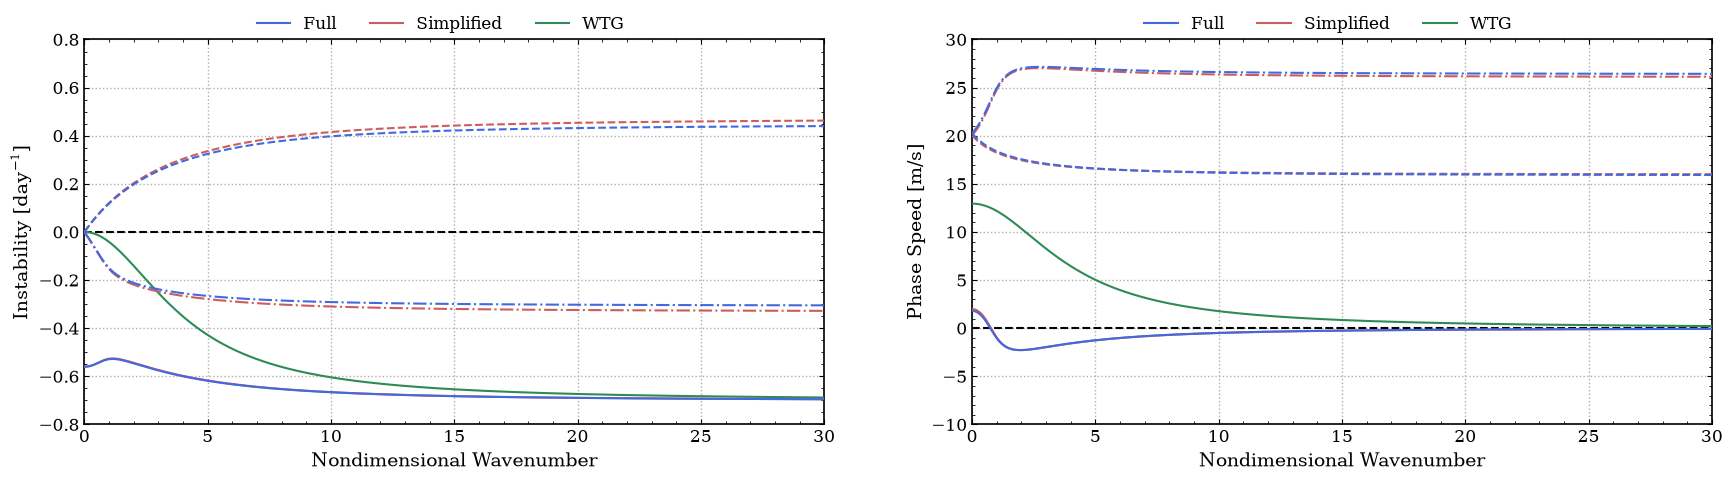

In [72]:
# line style list
line_style = ["-", "--", "-."]

# universal figure setting
plt.rcParams.update({
        "font.family": "serif", 
        "mathtext.fontset": "cm",
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "axes.linewidth": 1.2
    })

fig, ax = plt.subplots(1, 2, figsize=(21, 5))

for i in range(instab["full"].shape[1]):

    if i == 0:
        ax[0].plot(
            k, instab["full"][:, i],
            color="royalblue", linestyle=line_style[i],
            label="Full", zorder=100+i
            )
        ax[0].plot(
            k, instab["simplified"][:, i],
            color="indianred", linestyle=line_style[i],
            label="Simplified", zorder=50+i
            )

        ax[1].plot(
            k, pspeed["full"][:, i],
            color="royalblue", linestyle=line_style[i],
            label="Full", zorder=100+i
            )
        ax[1].plot(
            k, pspeed["simplified"][:, i],
            color="indianred", linestyle=line_style[i],
            label="Simplified", zorder=50+i
            )

    else:
        ax[0].plot(
            k, instab["full"][:, i],
            color="royalblue", linestyle=line_style[i],
            zorder=100+i
            )
        ax[0].plot(
            k, instab["simplified"][:, i],
            color="indianred", linestyle=line_style[i],
            zorder=50+i
            )
        ax[1].plot(
            k, pspeed["full"][:, i],
            color="royalblue", linestyle=line_style[i],
            zorder=100+i
            )
        ax[1].plot(
            k, pspeed["simplified"][:, i],
            color="indianred", linestyle=line_style[i],
            zorder=50+i
            )

ax[0].plot(k, instab["WTG"][:], color="seagreen", label="WTG", zorder=10)
ax[1].plot(k, pspeed["WTG"][:], color="seagreen", label="WTG", zorder=10)

ax[0].axhline(0, color="k", linestyle="--")
ax[0].minorticks_on()
ax[0].set_xlim(0, 30)
ax[0].set_ylim(-0.8, 0.8)
ax[0].set_xlabel("Nondimensional Wavenumber")
ax[0].set_ylabel(r"Instability [day$^{-1}$]")
ax[0].legend(edgecolor="k", bbox_to_anchor=(0.75, 1.1), ncol=3, frameon=False)
ax[0].grid(linestyle=":", linewidth=1)


ax[1].axhline(0, color="k", linestyle="--")
ax[1].minorticks_on()
ax[1].set_xlim(0, 30)
ax[1].set_ylim(-10, 30)
ax[1].set_xlabel("Nondimensional Wavenumber")
ax[1].set_ylabel("Phase Speed [m/s]")
ax[1].legend(edgecolor="k", bbox_to_anchor=(0.75, 1.1), ncol=3, frameon=False)
ax[1].grid(linestyle=":", linewidth=1)

plt.savefig(root_dir / "Figure" / "Compare.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)